In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import r2_score,precision_score,f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree

In [2]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


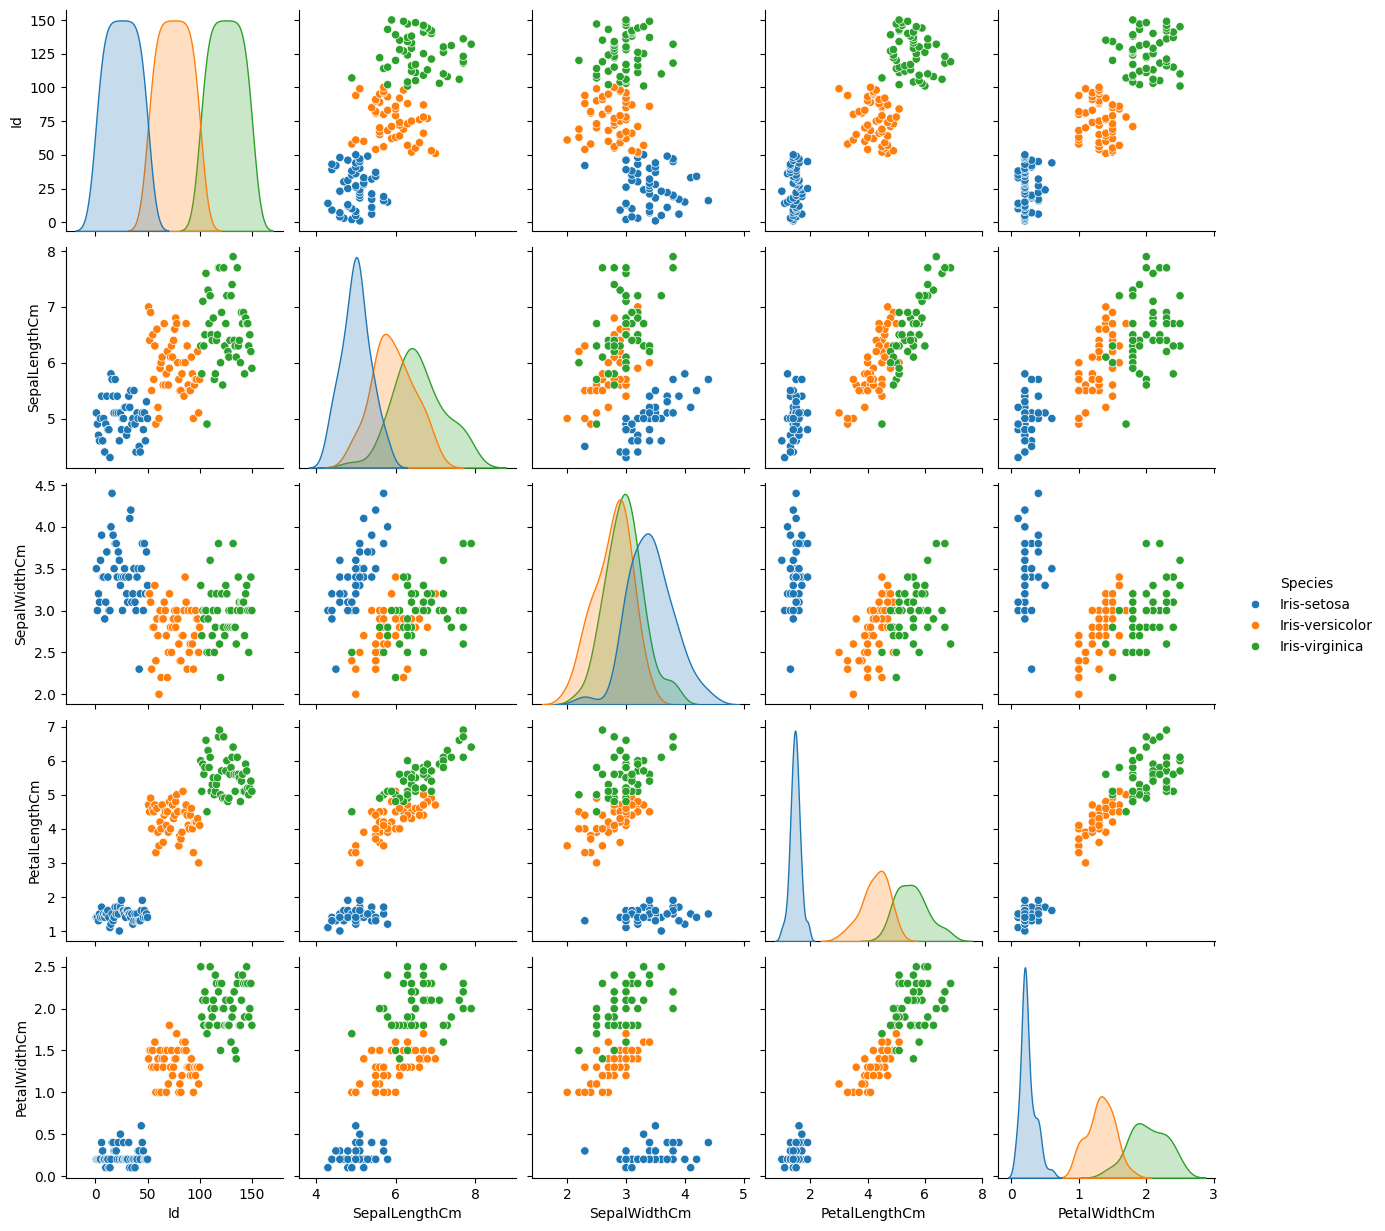

In [3]:
sns.pairplot(data=df, hue='Species')
plt.show()

In [4]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
le = LabelEncoder()

df['Species'] = le.fit_transform(df['Species'])

In [7]:
correlation = df.corr()

<Axes: >

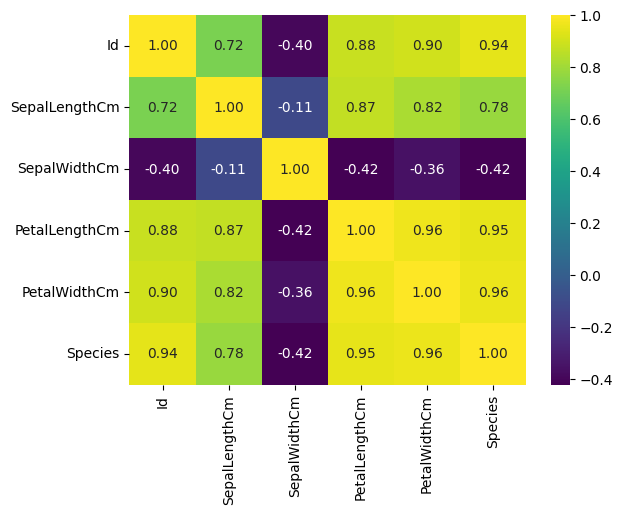

In [8]:
sns.heatmap(data = correlation, cmap='viridis', fmt='.2f', annot=True)

In [9]:
X= df.iloc[:,1:-1]
y=df['Species']

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42, test_size=0.2)

## Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier 

In [13]:
dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
dt_train = dt.predict(X_train) 
dt_test = dt.predict(X_test)

In [15]:
precision_score(y_test,dt_test, average='macro')

1.0

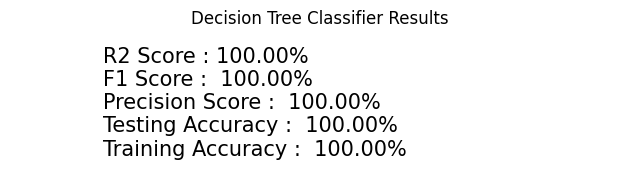

<Figure size 1000x1000 with 0 Axes>

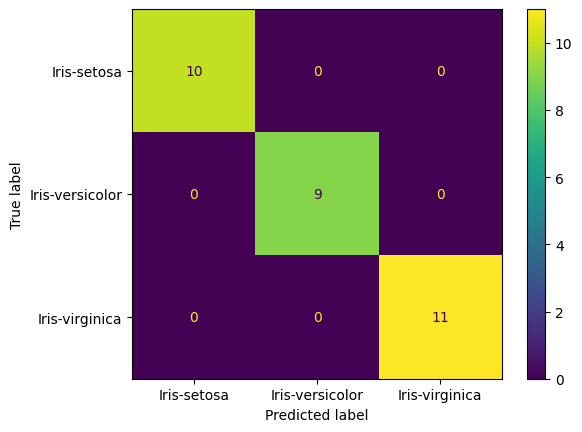

In [16]:
# Decision Tree Classifier Results
plt.figure(figsize=(8,2))
plt.axis('off')
plt.title("Decision Tree Classifier Results")
plt.text(0.15,.80,f"R2 Score : {r2_score(y_test,dt_test)*100:.2f}%",fontsize=15, ha='left')
plt.text(0.15,.65,f"F1 Score : {f1_score(y_test,dt_test, average='macro')*100 : .2f}%",fontsize=15, ha='left')
plt.text(0.15,.50,f"Precision Score : {precision_score(y_test,dt_test, average='macro')*100 : .2f}%",fontsize=15, ha='left')
plt.text(0.15,.35,f"Testing Accuracy : {accuracy_score(y_test,dt_test)*100 : .2f}%",fontsize=15, ha='left')
plt.text(0.15,.20,f"Training Accuracy : {accuracy_score(y_train,dt_train)*100 : .2f}%",fontsize=15, ha='left')
plt.show()

#Confusion Matrix
plt.figure(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_test,dt_test, display_labels=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])

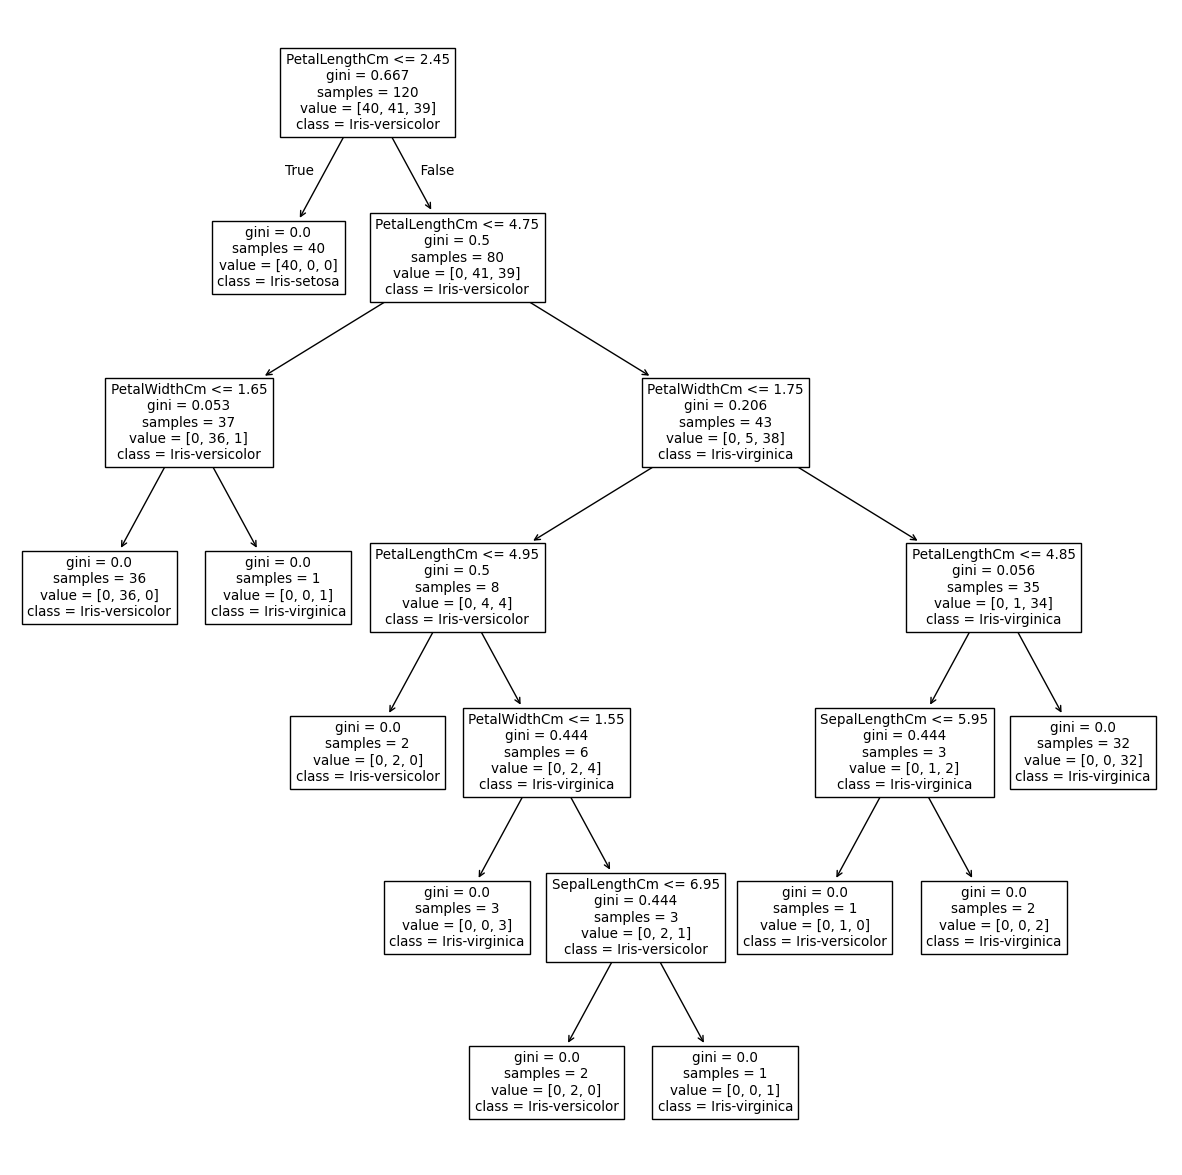

In [17]:
# Plot tree 
plt.figure(figsize=(15,15))
plot_tree(dt, feature_names=X_train.columns, 
         class_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
plt.show()

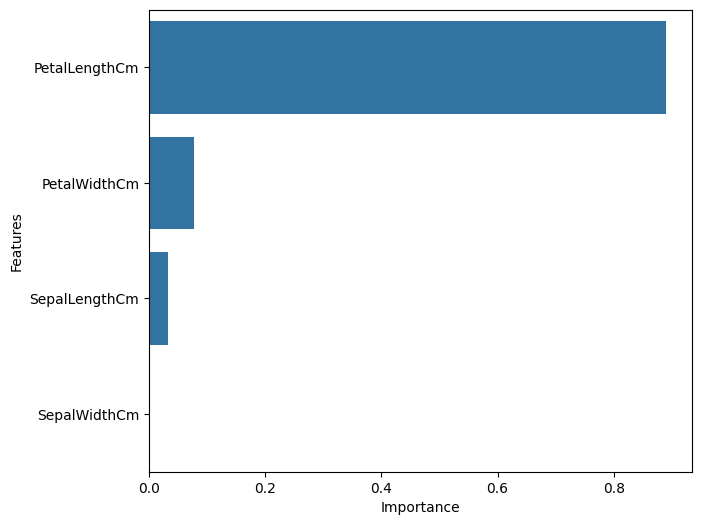

In [18]:
feature_importance = pd.DataFrame({
    'Features' : X.columns , 
    'Importance' : dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7,6))
sns.barplot(x='Importance', y='Features', data=feature_importance)
plt.show()